In [1]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# SNE/t-SNE explanation

## Stochastic Neighbor Embedding (SNE)

SNE tries to find a low dimensional (i.e., 2/3D) projection of a high dimensional dataset that preserves similarity.
That is, points that are close in the high dimensional space should also be close in the projection, whereas far away points do not necessarily have to be far away in the projection. Is is done by modelling similarities as conditional probabilities, so the similarity of points $x_i$ and $x_j$ in the high-dimensional space is given by
$$
    p_{j\mid i} = \frac{\exp(-\lVert x_i - x_j\rVert^2/2\sigma_i^2)}{\sum_{k\neq i}\exp(-\lVert x_i - x_k\rVert^2/2\sigma_i^2)}.
$$
So we use a Gaussian kernel centered at $x_i$ to randomly pick a neighbor, close points (w.r.t euclidian distance) are more likely to be picked and the probability of $x_j$ being picked as the neighbor of $x_i$ is used as the similarity score between $x_i$ and $x_j$.

Similarly, the similarity in the low dimensional space is also defined as a conditional probability using a Gaussian kernel, here we uses a fixed variance $\sigma^2$ for all $y_i$. That is, the similarity between $y_i$ and $y_j$ is given by
$$
    q_{j\mid i} = \frac{\exp(-\lVert y_i - y_j\rVert^2)}{\sum_{k\neq i}\exp(-\lVert y_i - y_k\rVert^2)}.
$$
We now have $2n$ distributions $P_i, Q_i$ and want to make them as similar as possible to preserve the similarity measures between the points. To achieve this, we can use gradient descent on the cost function
$$
    C = \sum_{i}\mathrm{KL}(P_i\Vert Q_i) = \sum_i\sum_j p_{j\mid i}\log{\frac{p_{j\mid i}}{q_{j\mid i}}}.
$$
Due to the asymmetry of the KL divergence, positioning similar points far away is penalized more severly than positioning dissimilar points close together.

## t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE is an adaption of vanilla SNE. The problem with SNE is that the cost function $C$ is difficult to optimize and can lead to crowding. To alleviate these issues, t-SNE uses a symmetric similarity measure and a the $t$-distribution to model similarities in the low dimensional space. The heavier tails of the $t$-distribution counteract the crowding problem as they allow moderate distances in the high dimensional space to be modelled accurately by a somewhat large distance in the low dimensional space.

# Implementation

In [2]:
df = pd.read_csv("train_data_yeo_new.csv")

In [3]:
con = sqlite3.connect("../backend-project/data/Players.db")
cur = con.cursor()

In [4]:
categories = {
    "Boxscore": ["points", "points per player's possession", "field goals made",
       "field goals attempted", "3-pt field goals made",
       "3-pt field goals attempted", "free throws made",
       "free throws attempted", "rebounds",
       "offensive rebounds", "defensive rebounds", "assists", "steals",
       "turnovers", "blocks", "fouls", "fouls drawn", 
       "2-pt field goals made", "2-pt field goals attempted",
       "points off assists", "screen assist",
       "points off screen assists"],
    "Advanced Boxscore": ["number of player's possessions",
       "team points with player", "offensive rating",
       "opponent possessions played", "opponent's points with player",
       "defensive rating", "plus/minus", "net rating", "assists to turnovers",
       "steals to turnovers", "draw foul rate", "true shooting percentage",
       "effective field goal percentage"],
    "Additional Field Goal Data": ["uncontested field goals made",
                                   "uncontested field goals",
                                   "contested field goals made",
                                   "contested field goals",
                                   "opponent's field goals made",
                                   "opponent's field goals attempted"],
    "Play Type Combinations": [
        "transitions made", "transitions attempted",
        "catch and shoot made", "catch and shoot attempted",
        "catch and drive made", "catch and drive attempted",
        "screens off made", "screens off attempted",
        "posts up made", "posts up attempted",
        "isolations made", "isolations attempted",
        "hand off made", "hand off attempted",
        "cuts made", "cuts attempted",
        "pnr handlers made", "pnr handlers attempted",
        "pnr rollers made", "pnr rollers attempted",
        "pnp made", "pnp attempted",
    ],
    
    "Defense Against Play Type Combinations": [
        "opp transition shots made", "opp transition shots",
        "opp catch and shoot shots made", "opp catch and shoot shots",
        "opp catch and drive shots made", "opp catch and drive shots",
        "opp screens off shots made", "opp screens off shots",
        "opp post up shots made", "opp post up shots",
        "opp isolations shots made", "opp isolations shots",
        "opp hand off shots made", "opp hand off shots",
        "opp cuts shots made", "opp cuts shots",
        "opp pick-n-roll shots made", "opp pick-n-roll shots",
        "opp pick-n-pop shots made", "opp pick-n-pop shots",
    ],
    
    "Drivers": [
        "drives made", "drives with shot",
        "right drives made", "right drives",
        "left drives made", "left drives",
    ],
    
    "Drivers Defense": ["opp drives shots made", "opp drives shots"],
}


Calculating Boxscore projection
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2105 samples in 0.001s...
[t-SNE] Computed neighbors for 2105 samples in 0.171s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2105
[t-SNE] Computed conditional probabilities for sample 2000 / 2105
[t-SNE] Computed conditional probabilities for sample 2105 / 2105
[t-SNE] Mean sigma: 0.063038
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.006538
[t-SNE] KL divergence after 1000 iterations: 1.352760


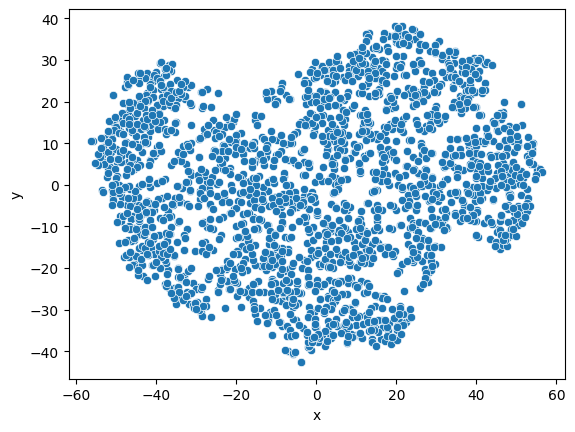

Inserting into database
Calculating Advanced Boxscore projection
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2105 samples in 0.011s...
[t-SNE] Computed neighbors for 2105 samples in 0.067s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2105
[t-SNE] Computed conditional probabilities for sample 2000 / 2105
[t-SNE] Computed conditional probabilities for sample 2105 / 2105
[t-SNE] Mean sigma: 0.166554
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.586540
[t-SNE] KL divergence after 1000 iterations: 0.765720


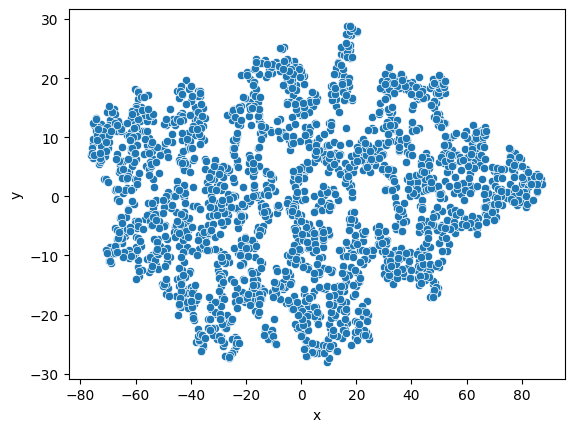

Inserting into database
Calculating Additional Field Goal Data projection
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2105 samples in 0.001s...
[t-SNE] Computed neighbors for 2105 samples in 0.042s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2105
[t-SNE] Computed conditional probabilities for sample 2000 / 2105
[t-SNE] Computed conditional probabilities for sample 2105 / 2105
[t-SNE] Mean sigma: 0.018572
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.605621
[t-SNE] KL divergence after 1000 iterations: 1.106822


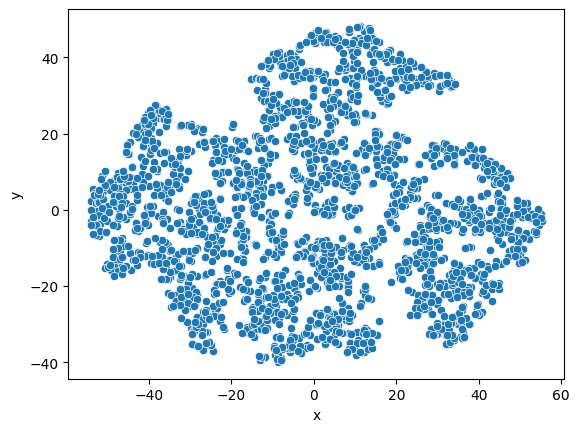

Inserting into database
Calculating Play Type Combinations projection
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2105 samples in 0.000s...
[t-SNE] Computed neighbors for 2105 samples in 0.054s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2105
[t-SNE] Computed conditional probabilities for sample 2000 / 2105
[t-SNE] Computed conditional probabilities for sample 2105 / 2105
[t-SNE] Mean sigma: 0.043633
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.149544
[t-SNE] KL divergence after 1000 iterations: 1.259668


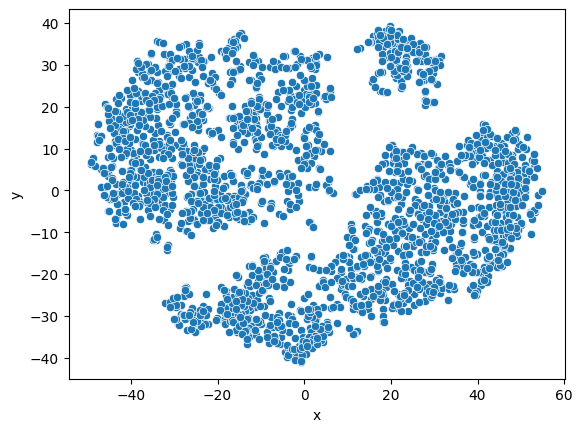

Inserting into database
Calculating Defense Against Play Type Combinations projection
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2105 samples in 0.000s...
[t-SNE] Computed neighbors for 2105 samples in 0.036s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2105
[t-SNE] Computed conditional probabilities for sample 2000 / 2105
[t-SNE] Computed conditional probabilities for sample 2105 / 2105
[t-SNE] Mean sigma: 0.021234
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.411682
[t-SNE] KL divergence after 1000 iterations: 1.232313


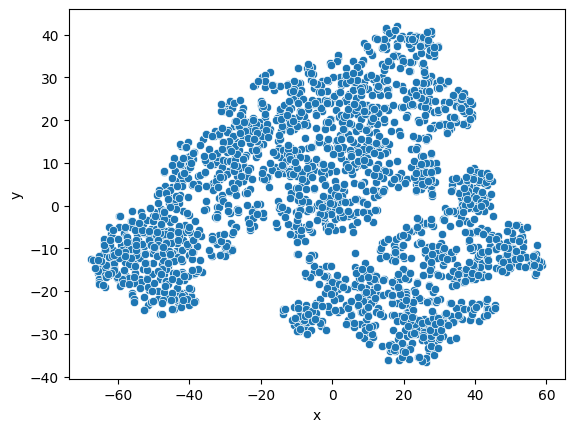

Inserting into database
Calculating Drivers projection
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2105 samples in 0.001s...
[t-SNE] Computed neighbors for 2105 samples in 0.040s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2105
[t-SNE] Computed conditional probabilities for sample 2000 / 2105
[t-SNE] Computed conditional probabilities for sample 2105 / 2105
[t-SNE] Mean sigma: 0.013291
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.919807
[t-SNE] KL divergence after 1000 iterations: 0.866033


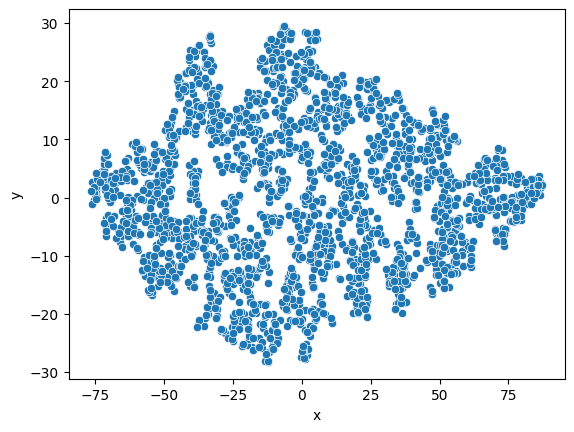

Inserting into database
Calculating Drivers Defense projection
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2105 samples in 0.001s...
[t-SNE] Computed neighbors for 2105 samples in 0.028s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2105
[t-SNE] Computed conditional probabilities for sample 2000 / 2105
[t-SNE] Computed conditional probabilities for sample 2105 / 2105
[t-SNE] Mean sigma: 0.001236
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.308594
[t-SNE] KL divergence after 1000 iterations: 0.538114


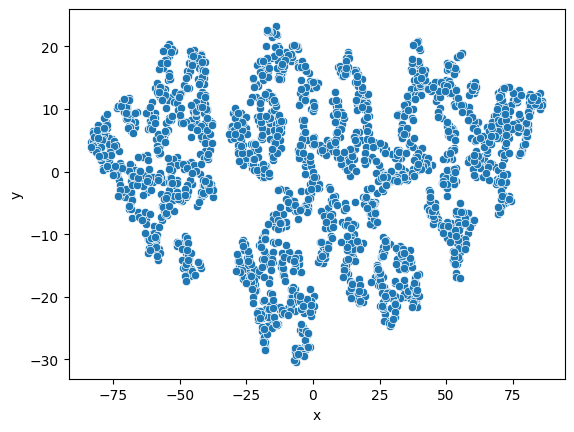

Inserting into database


<Figure size 640x480 with 0 Axes>

In [5]:
# Project into 2d using t-SNE
for cat in categories.keys():
    print(f"Calculating {cat} projection")
    proj = TSNE(verbose=1).fit_transform(df[categories[cat]])
    proj_df = pd.DataFrame(proj).rename({0: "x", 1: "y"}, axis="columns")
    plt.close()
    sns.scatterplot(data=proj_df, x="x", y="y");
    plt.show();
    plt.savefig(f"{cat}_projection.png")
    
    print("Inserting into database")
    for i, (x, y) in enumerate(proj):
        cat_name = cat.replace(" ", "_").lower()
        escaped_name = df.loc[i]["player name"].replace("'", "''")
        #con.execute(f"UPDATE Player SET x_{cat_name} = {x}, y_{cat_name} = {y} WHERE name = '{escaped_name}';")

#con.commit()
#con.close()

In [5]:
con.close()